In [1]:
import os
print(os.getcwd())


C:\Users\sudar\PycharmProjects\FinBot\notebook


In [5]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [6]:
data_path = Path("C:/Users/sudar/PycharmProjects/FinBot/artifacts/data/credit_risk_dataset.csv")

In [7]:
data = pd.read_csv(data_path)

| Column Name             | Meaning                                                                     |
| ----------------------- | --------------------------------------------------------------------------- |
| `person_age`            | Age of the loan applicant.                                                  |
| `person_income`         | Annual income of the person (likely in USD).                                |
| `person_home_ownership` | Type of home ownership: `RENT`, `OWN`, `MORTGAGE`, etc.                     |
| `person_emp_length`     | Length of employment in months or years (e.g., 123.0 months ≈ 10.25 years). |

| Column Name           | Meaning                                                                                  |
| --------------------- | ---------------------------------------------------------------------------------------- |
| `loan_intent`         | Purpose of the loan (e.g., `PERSONAL`, `EDUCATION`, `MEDICAL`).                          |
| `loan_grade`          | Internal grade assigned to the loan (A to G, where A is highest quality, G is riskiest). |
| `loan_amnt`           | Amount of loan requested or approved.                                                    |
| `loan_int_rate`       | Interest rate for the loan (%).                                                          |
| `loan_percent_income` | Loan amount as a fraction of the person’s income. A value of `0.59` means 59% of income. |


| Column Name   | Meaning                                                                                                               |
| ------------- | --------------------------------------------------------------------------------------------------------------------- |
| `loan_status` | Whether the person **defaulted** (`1`) or **repaid** (`0`). This is your **target** column in a classification model. |

| Column Name                  | Meaning                                                                                           |
| ---------------------------- | ------------------------------------------------------------------------------------------------- |
| `cb_person_default_on_file`  | Whether the applicant has previously defaulted (`Y` for Yes, `N` for No).                         |
| `cb_person_cred_hist_length` | Credit history length (likely in years). Longer history usually suggests better creditworthiness. |



In [8]:
data.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### This suggest the missing value of `person_emp_length` might MAR(missing at random) which corelated with `cb_person_default_on_file` and `cb_person_cred_hist_length`.
### `loan_int_rate` is `MCAR` i.e complete random.

- Lets plot the `person_emp_length`

Text(0.5, 1.0, 'Distribution of person_emp_length')

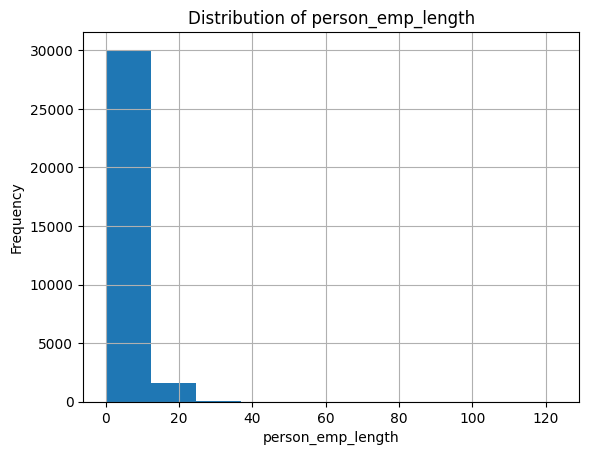

In [11]:
data['person_emp_length'].hist()
plt.xlabel('person_emp_length')
plt.ylabel('Frequency')
plt.title('Distribution of person_emp_length')

In [12]:
zero_count = (data['person_emp_length'] == 0).sum()
print("Count of zeros in person_emp_length:", zero_count)

Count of zeros in person_emp_length: 4105


- FILLING `person_emp_length` with KNN imputation. 

In [13]:
def preprocess_data(df):
    df_proc = df.copy()
    
    # Ordinal mapping
    grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    df_proc['loan_grade_ordinal'] = df_proc['loan_grade'].map(grade_map)
    
    # One-hot encode nominal features
    nominal_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe_encoded = pd.DataFrame(
        ohe.fit_transform(df_proc[nominal_cols]),
        columns=ohe.get_feature_names_out(nominal_cols),
        index=df_proc.index
    )
    
    df_proc = pd.concat([df_proc.drop(nominal_cols, axis=1), ohe_encoded], axis=1)
    
    return df_proc, ohe, grade_map


In [14]:
def knn_impute_employment(df, k=7):
    knn_features = [
        'person_age', 'person_income', 'loan_grade_ordinal', 'loan_amnt',
        'loan_percent_income', 'cb_person_cred_hist_length'
    ] + [col for col in df.columns if col.startswith(('person_home_ownership_', 'loan_intent_', 'cb_person_default_on_file_'))]
    
    knn_data = df[knn_features + ['person_emp_length']].copy()
    
    scaler = StandardScaler()
    knn_data_scaled = knn_data.copy()
    knn_data_scaled[knn_features] = scaler.fit_transform(knn_data[knn_features])
    
    imputer = KNNImputer(n_neighbors=k, weights='distance')
    imputed = imputer.fit_transform(knn_data_scaled)
    
    df_out = df.copy()
    df_out['person_emp_length'] = imputed[:, -1]
    
    return df_out, imputer, scaler


In [15]:
def iterative_impute_interest(df):
    iter_features = [
        'person_age', 'person_income', 'loan_grade_ordinal',
        'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length',
        'person_emp_length'
    ] + [col for col in df.columns if col.startswith(('person_home_ownership_', 'loan_intent_', 'cb_person_default_on_file_'))]
    
    iter_data = df[iter_features + ['loan_int_rate']].copy()
    
    imputer = IterativeImputer(random_state=0, max_iter=10)
    imputed = imputer.fit_transform(iter_data)
    
    df_out = df.copy()
    df_out['loan_int_rate'] = imputed[:, -1]
    
    return df_out, imputer


In [18]:
def full_preprocessing_pipeline(raw_data):
    # Step 1: Preprocess (encode)
    df_proc, ohe_encoder, grade_map = preprocess_data(raw_data)

    # Step 2: KNN imputation
    df_knn, knn_imputer, knn_scaler = knn_impute_employment(df_proc)

    # Step 3: Iterative imputation
    df_final, iter_imputer = iterative_impute_interest(df_knn)
    

    
    # Save models
    # joblib.dump(ohe_encoder, r'C:\Users\sudar\PycharmProjects\FinBot\artifacts\models\ohe_encoder.pkl')
    # joblib.dump(grade_map, r'C:\Users\sudar\PycharmProjects\FinBot\artifacts\models\grade_map.pkl')
    # joblib.dump(knn_imputer, r'C:\Users\sudar\PycharmProjects\FinBot\artifacts\models\knn_imputer.pkl')
    # joblib.dump(knn_scaler, r'C:\Users\sudar\PycharmProjects\FinBot\artifacts\models\knn_scaler.pkl')
    # joblib.dump(iter_imputer, r'C:\Users\sudar\PycharmProjects\FinBot\artifacts\models\iterative_imputer.pkl')
    
    return df_final


In [19]:
clean_data = full_preprocessing_pipeline(data)

In [20]:
clean_data.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_grade_ordinal,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_N,cb_person_default_on_file_Y
0,22,59000,123.0,D,35000,16.02,1,0.59,3,4,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,21,9600,5.0,B,1000,11.14,0,0.10,2,2,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,25,9600,1.0,C,5500,12.87,1,0.57,3,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,23,65500,4.0,C,35000,15.23,1,0.53,2,3,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,24,54400,8.0,C,35000,14.27,1,0.55,4,3,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [21]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      32581 non-null  int64  
 1   person_income                   32581 non-null  int64  
 2   person_emp_length               32581 non-null  float64
 3   loan_grade                      32581 non-null  object 
 4   loan_amnt                       32581 non-null  int64  
 5   loan_int_rate                   32581 non-null  float64
 6   loan_status                     32581 non-null  int64  
 7   loan_percent_income             32581 non-null  float64
 8   cb_person_cred_hist_length      32581 non-null  int64  
 9   loan_grade_ordinal              32581 non-null  int64  
 10  person_home_ownership_MORTGAGE  32581 non-null  float64
 11  person_home_ownership_OTHER     32581 non-null  float64
 12  person_home_ownership_OWN       

In [22]:
analysis_df = data.copy(deep=True)

In [23]:
analysis_df['person_emp_length'] = clean_data['person_emp_length']

In [24]:
analysis_df['loan_int_rate'] = clean_data['loan_int_rate']

In [25]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [26]:
numeric_columns = analysis_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric Columns:", numeric_columns)

categorical_columns = analysis_df.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", categorical_columns)

Numeric Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical Columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [27]:
analysis_df[numeric_columns].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.781191,9589.371106,11.007482,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.100532,6322.086646,3.214097,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.230000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.387220,1.000000,0.830000,30.000000


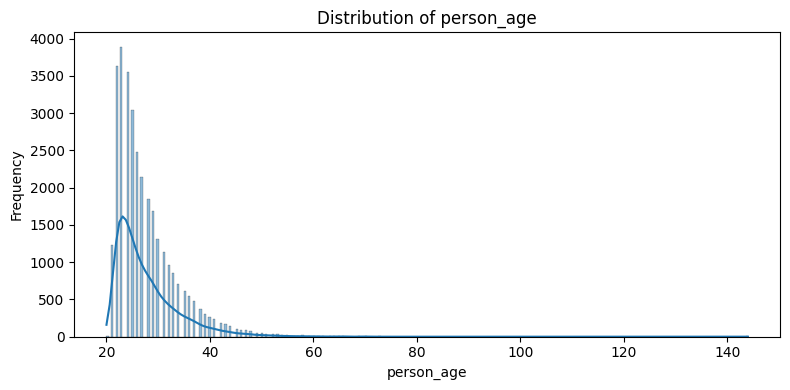

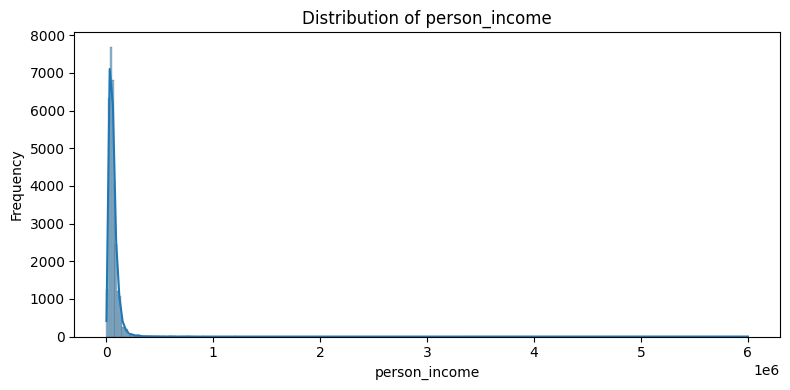

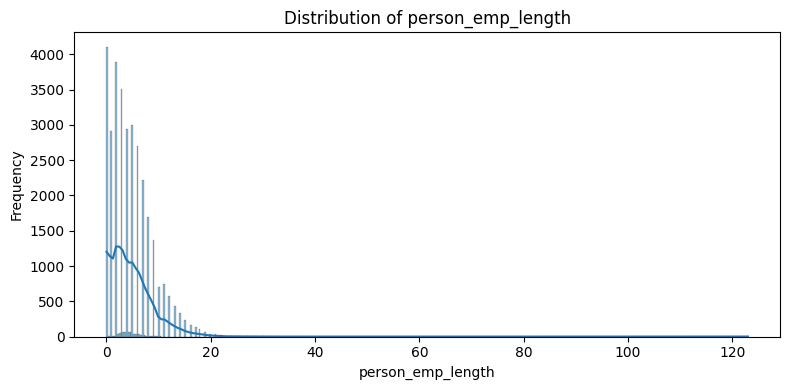

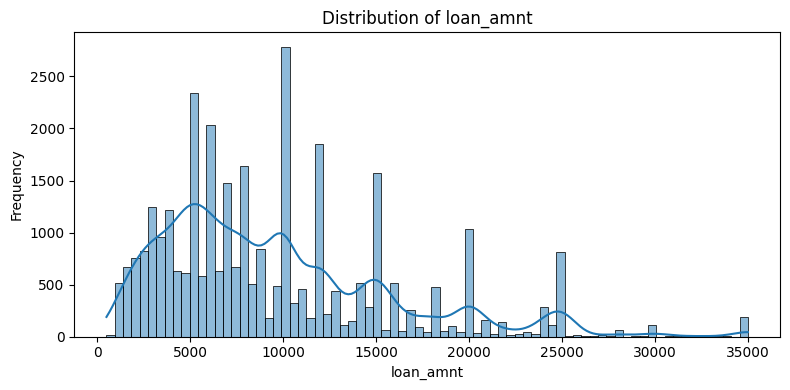

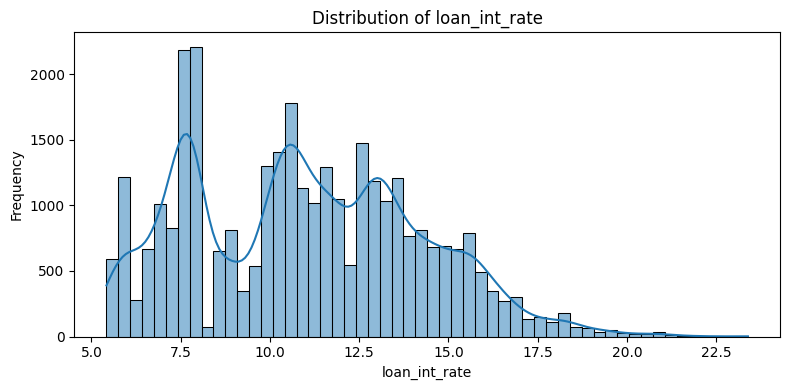

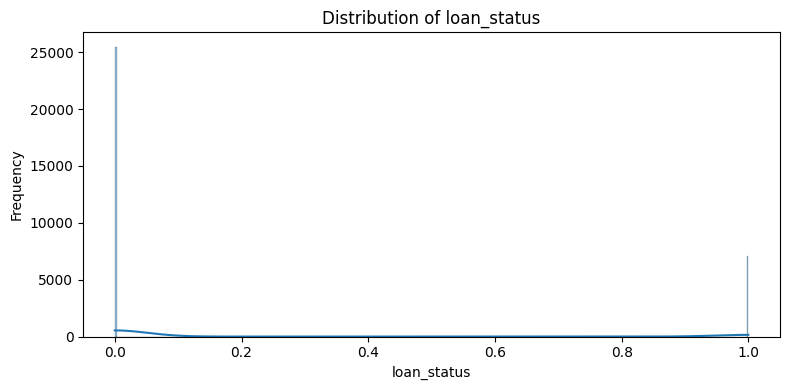

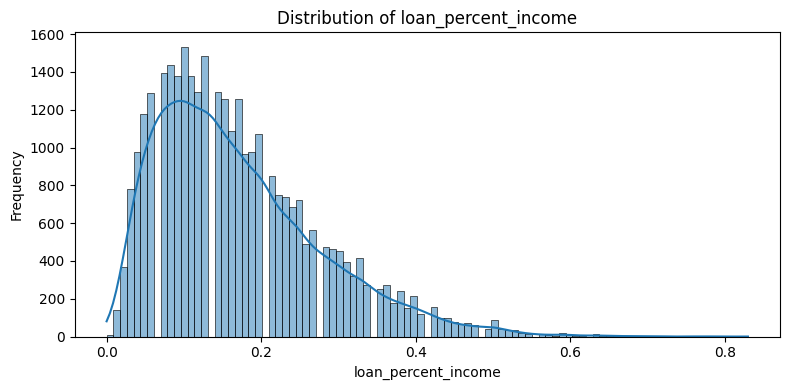

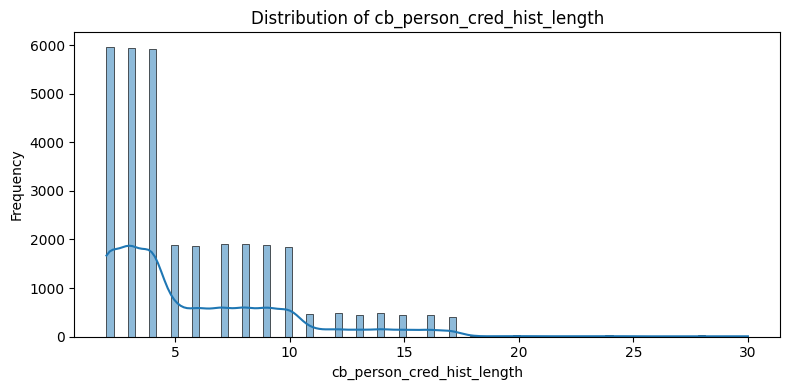

In [28]:
for name in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(analysis_df[name], kde=True)
    plt.title(f'Distribution of {name}')
    plt.xlabel(name)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

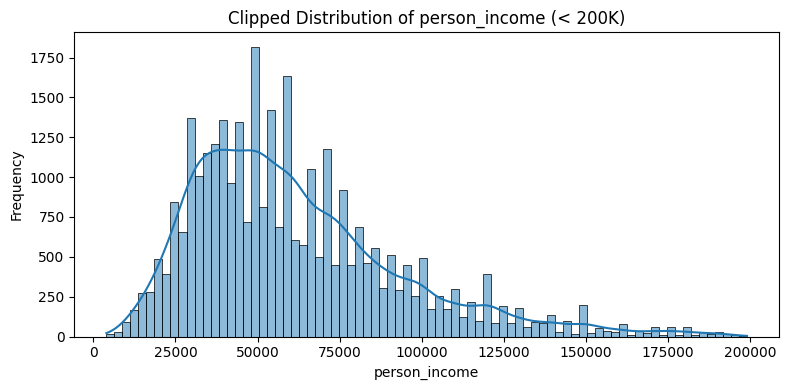

In [29]:
plt.figure(figsize=(8, 4))
sns.histplot(analysis_df[analysis_df['person_income'] < 200000]['person_income'], kde=True)
plt.title('Clipped Distribution of person_income (< 200K)')
plt.xlabel('person_income')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## 📊 Numerical Univariate observations

* **`person_age`**:

  * Right-skewed distribution
  * Most people taking loans are between **20 to 40 years old**

* **`person_income`**:

  * Right-skewed
  * Majority of applicants have income **less than ₹125,000**

* **`person_emp_length`**:

  * Right-skewed
  * Most people have **less than 20 months** of employment experience

* **`loan_amnt`**:

  * Most people apply for a **loan amount less than ₹15,000**

* **`loan_int_rate`**:

  * Interest rates mostly fall between **7.5% to 17.5%**

* **`loan_percent_income`**:

  * Right-skewed
  * Most values fall under **0.4**, indicating that loan amounts are generally less than 40% of a person's income

* **`cb_person_cred_hist_length`**:

  * Most people have a **credit history length under 10 years**

* **`loan_status`**:

  * **Imbalanced class**
  * Majority of people **repay the loan**, while a smaller group **default or don't pay in full**


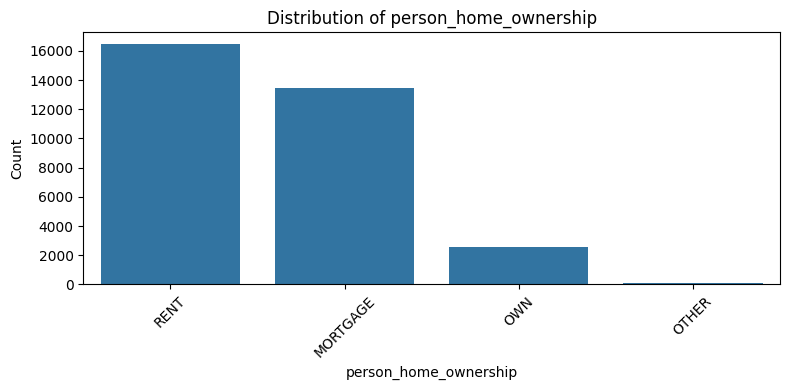

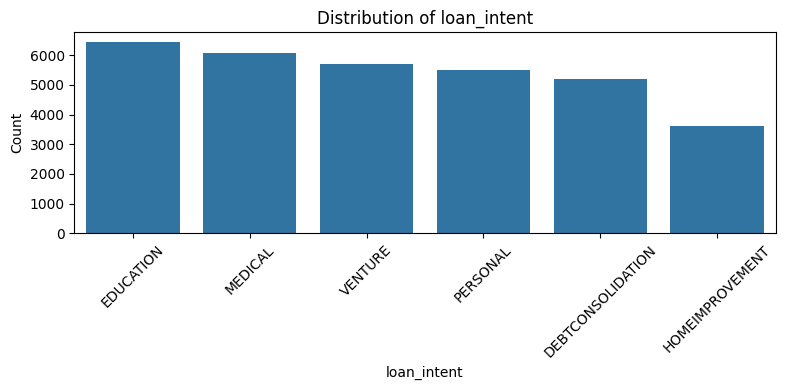

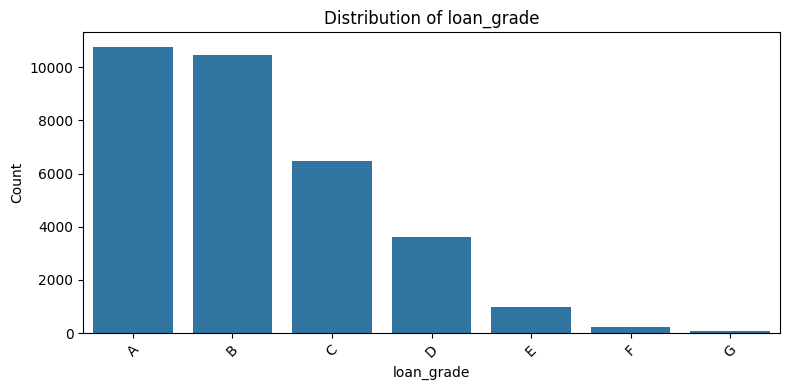

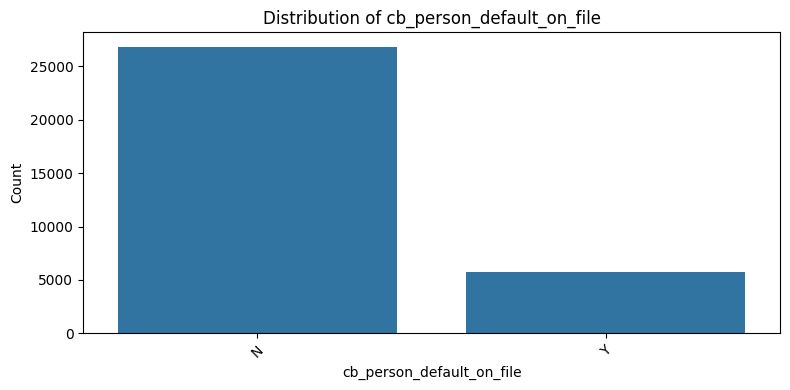

In [30]:
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=analysis_df, order=analysis_df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 📊 Categorical Feature Insights

* **Home Ownership**:
  Most people who take loans are **renting**, followed by those with **mortgage**, **own**, and a few categorized as **other**.

* **Loan Intent**:
  Loans are most commonly taken for **education**, followed by **medical**, **venture**, **personal**, **debt consolidation**, and **home improvement**.

* **Loan Grade**:
  The loan grades are distributed in the order: **A > B > C > D > E > F > G**, with **Grade A** being the most frequent.

* **Default Status**:
  The majority of people are **not defaulted**, while a smaller portion are **defaulted**.

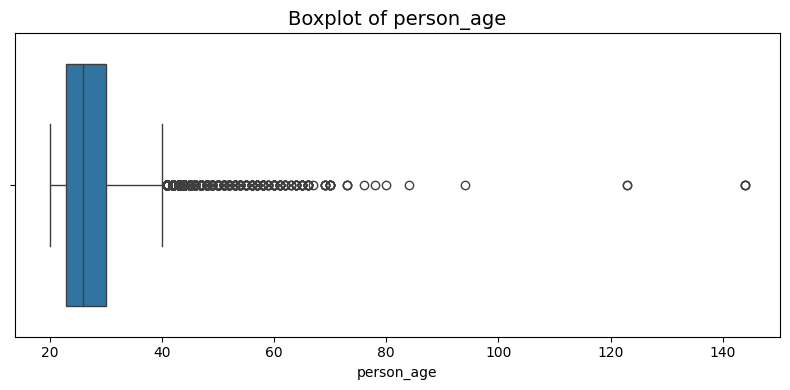

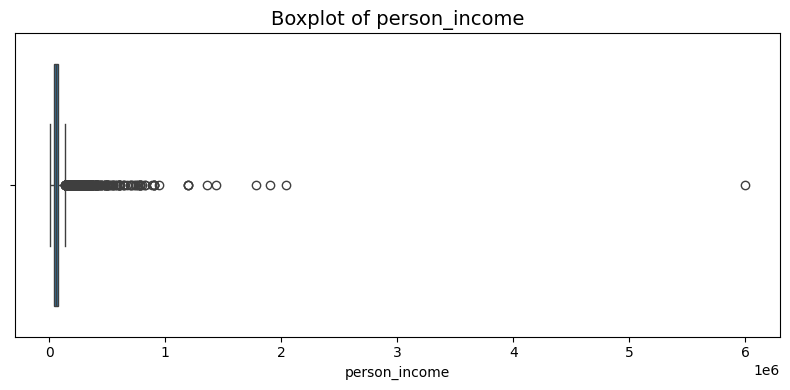

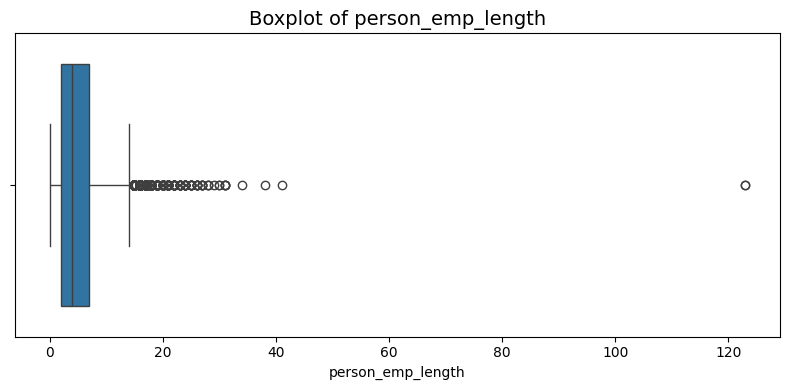

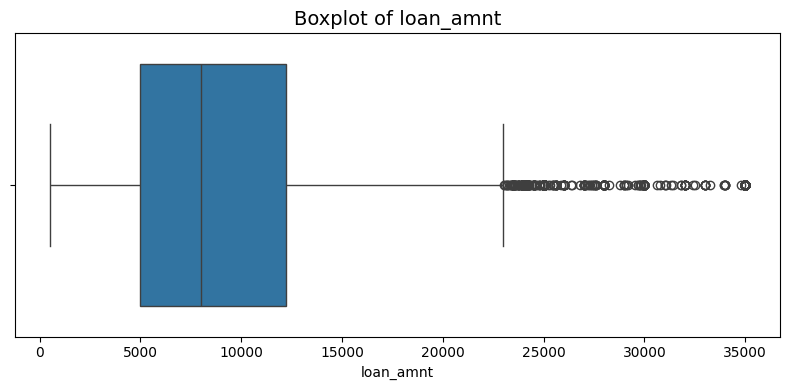

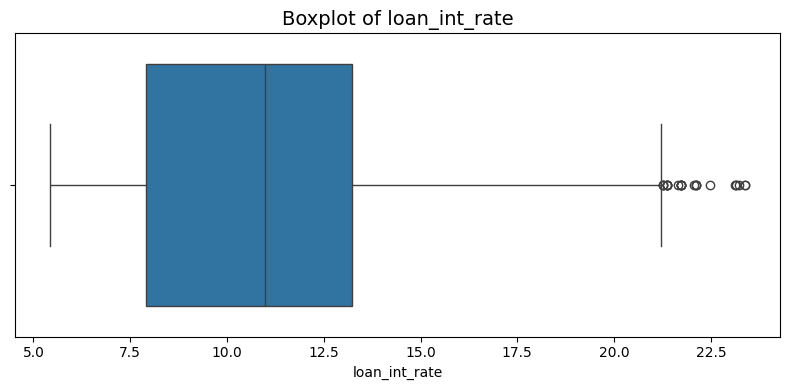

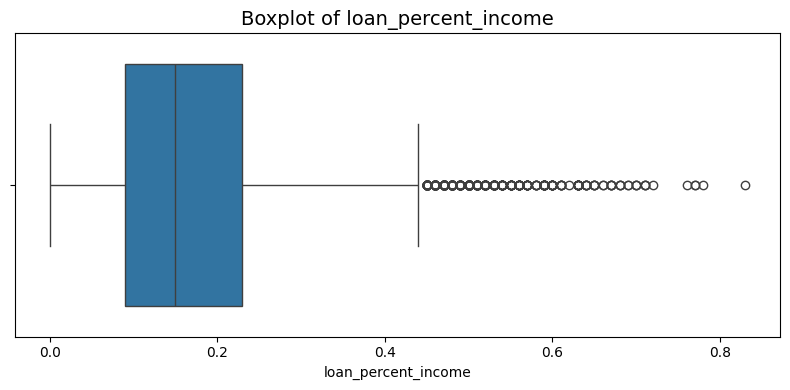

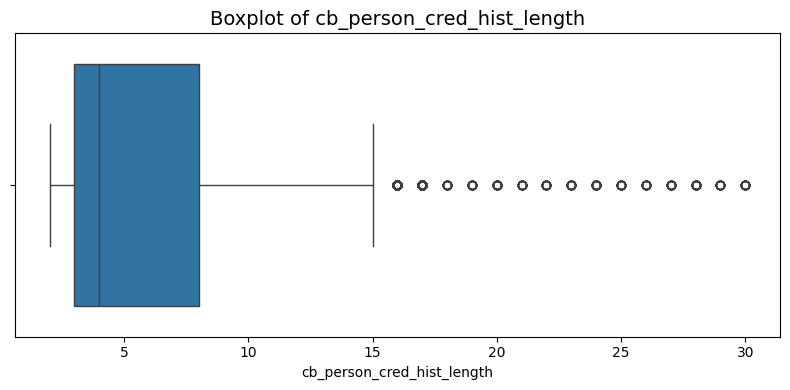

In [31]:
for col in numeric_columns:
    if col == 'loan_status':
        continue
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=analysis_df[col])
    plt.title(f'Boxplot of {col}', fontsize=14)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

C:\Users\sudar\AppData\Local\Temp\ipykernel_17956\377264263.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = analysis_df_binned.groupby(f'{col}_bin')['loan_status'].mean().reset_index()


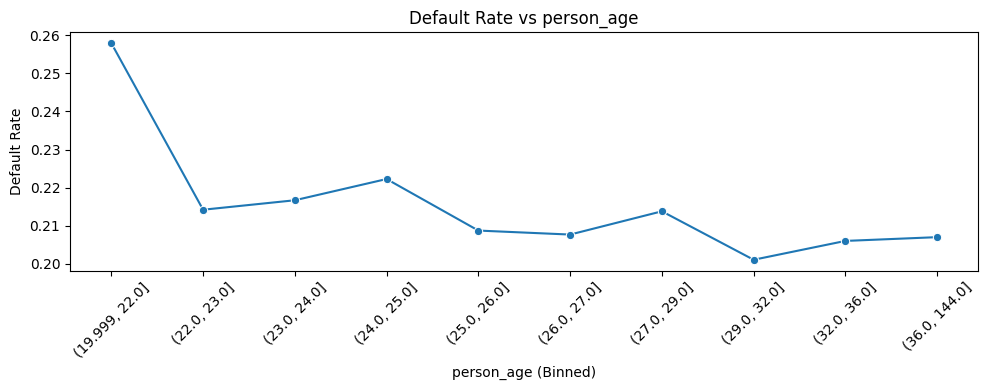

C:\Users\sudar\AppData\Local\Temp\ipykernel_17956\377264263.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = analysis_df_binned.groupby(f'{col}_bin')['loan_status'].mean().reset_index()


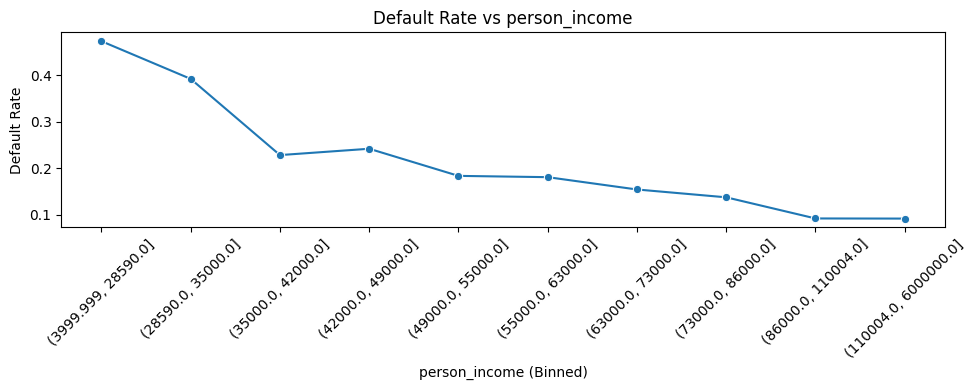

C:\Users\sudar\AppData\Local\Temp\ipykernel_17956\377264263.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = analysis_df_binned.groupby(f'{col}_bin')['loan_status'].mean().reset_index()


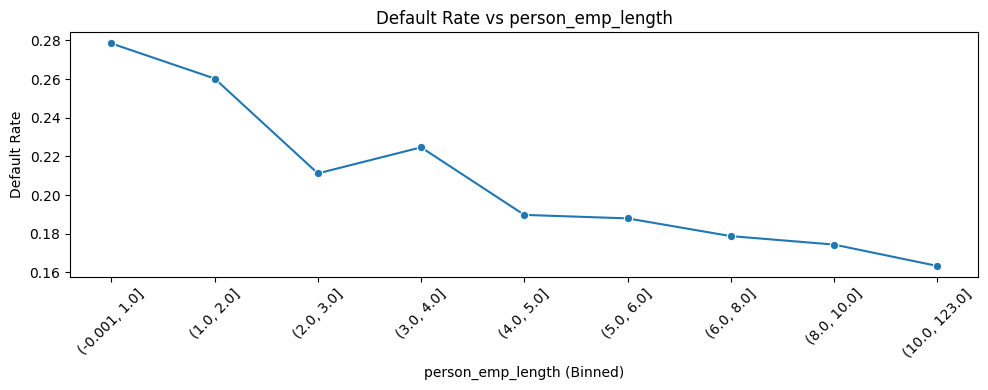

C:\Users\sudar\AppData\Local\Temp\ipykernel_17956\377264263.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = analysis_df_binned.groupby(f'{col}_bin')['loan_status'].mean().reset_index()


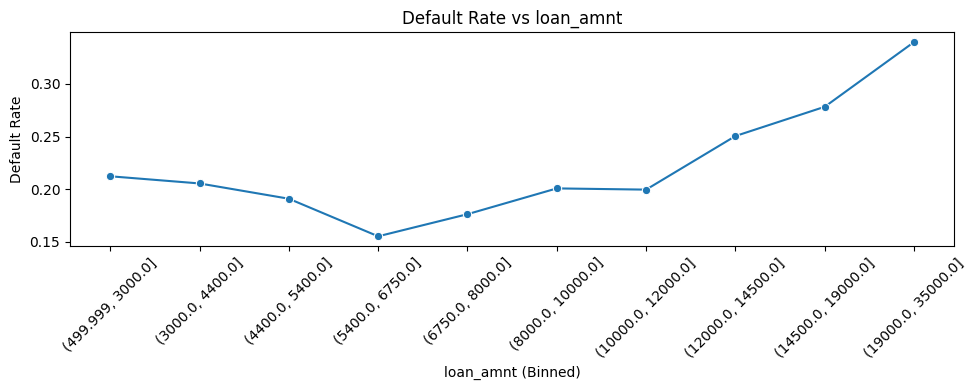

C:\Users\sudar\AppData\Local\Temp\ipykernel_17956\377264263.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = analysis_df_binned.groupby(f'{col}_bin')['loan_status'].mean().reset_index()


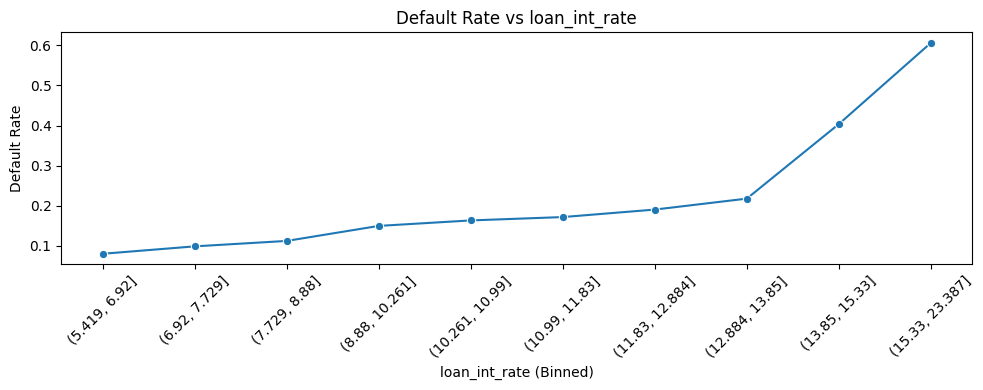

C:\Users\sudar\AppData\Local\Temp\ipykernel_17956\377264263.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = analysis_df_binned.groupby(f'{col}_bin')['loan_status'].mean().reset_index()


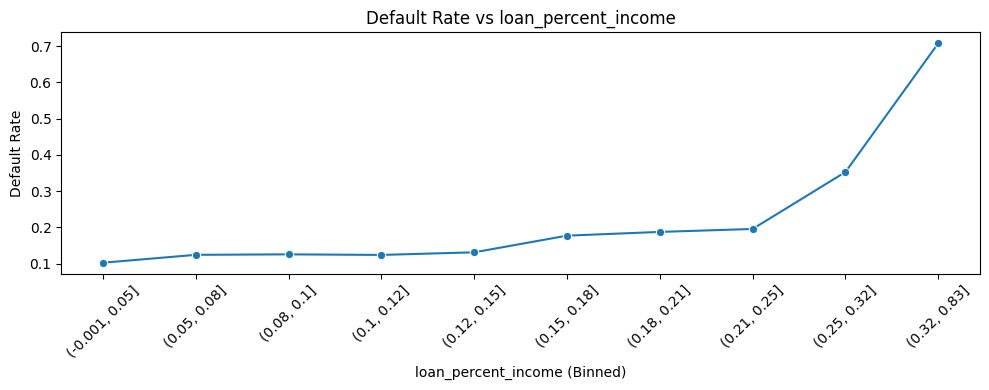

C:\Users\sudar\AppData\Local\Temp\ipykernel_17956\377264263.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = analysis_df_binned.groupby(f'{col}_bin')['loan_status'].mean().reset_index()


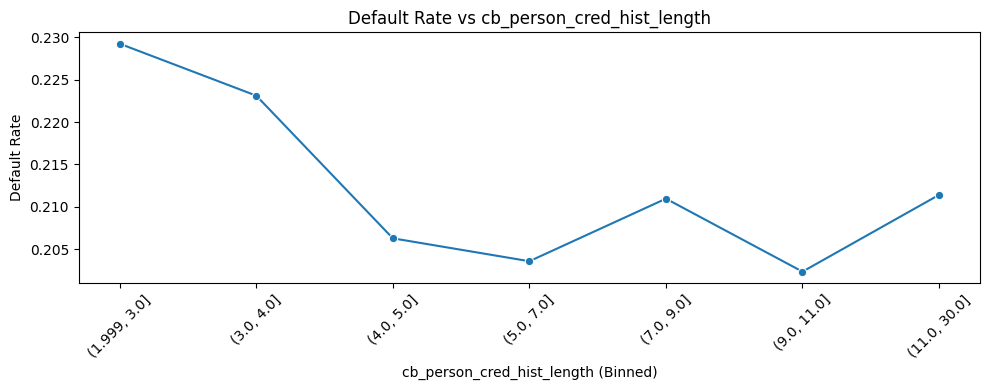

In [32]:

analysis_df_binned = analysis_df.copy()
bins = 10  # or use custom bin edges per variable

for col in numeric_columns:
    if col == 'loan_status':
        continue
    # Bin the variable
    analysis_df_binned[f'{col}_bin'] = pd.qcut(analysis_df[col], q=bins, duplicates='drop')

    # Group and compute mean loan_status (i.e., default rate)
    trend = analysis_df_binned.groupby(f'{col}_bin')['loan_status'].mean().reset_index()

    plt.figure(figsize=(10, 4))
    sns.lineplot(x=trend[f'{col}_bin'].astype(str), y=trend['loan_status'], marker='o')
    plt.xticks(rotation=45)
    plt.title(f'Default Rate vs {col}')
    plt.xlabel(f'{col} (Binned)')
    plt.ylabel('Default Rate')
    plt.tight_layout()
    plt.show()


# 📊 Credit Default Analysis Summary

This analysis highlights the characteristics of individuals who exhibit a **higher default ratio** in our credit risk dataset. The following patterns were observed among defaulters:

## 🔍 Key Observations

- **Age Group:** 19 to 22 years  
  Young applicants in this age range are more likely to default.

- **Income Range:** ₹3,999 to ₹28,590  
  Individuals with lower to moderate incomes show higher default tendencies.

- **Employment Length:** 0 to 3 years  
  Those with limited employment history are more prone to default.

- **Loan Amount Range:** ₹12,000 to ₹35,000  
  Loans in this range are more commonly associated with defaults.

- **Interest Rate Range:** 13.85% to 23.38%  
  Higher interest rates are a notable factor among defaulters.

- **Loan-to-Income Ratio:** 0.25 to 0.83  
  A higher portion of income going toward loan repayment indicates increased risk.

- **Credit History Length:** 1.99 to 4 years  
  Shorter credit histories correlate with higher default rates.


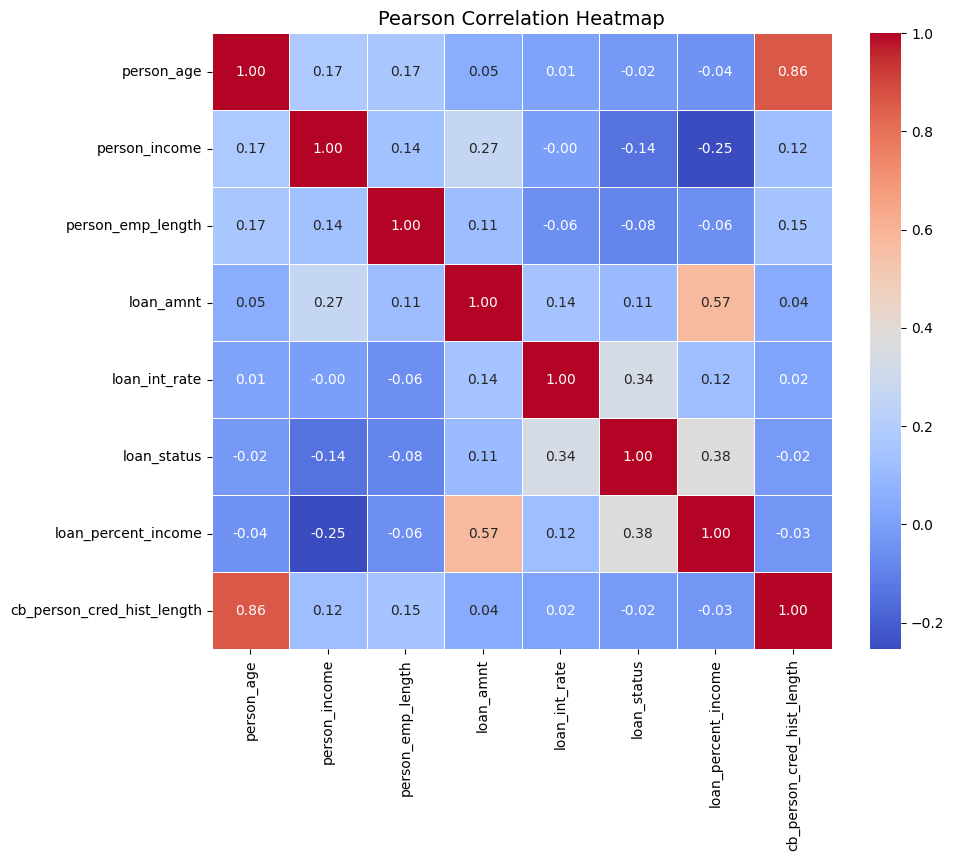

In [33]:
corr_matrix = analysis_df[numeric_columns].corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Pearson Correlation Heatmap", fontsize=14)
plt.show()

- So our data won't have high colinerity with loan status

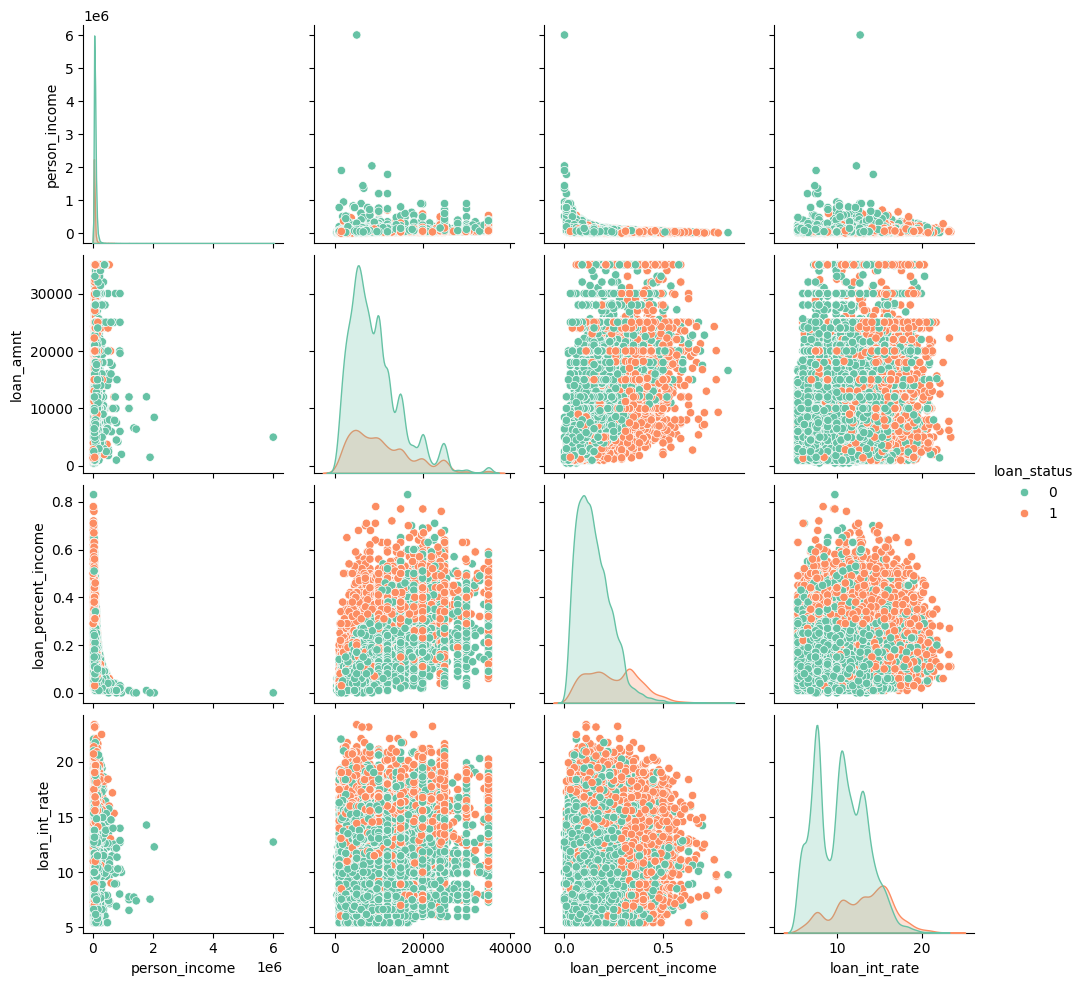

In [34]:
selected_columns = ['person_income', 'loan_amnt', 'loan_percent_income', 'loan_int_rate', 'loan_status']
sns.pairplot(analysis_df[selected_columns], hue='loan_status', palette='Set2')
plt.show()

In [45]:
save_csv = Path("../artifacts/data/filled_missing_value.csv")

analysis_df.to_csv(save_csv, index=False)